<a href="https://colab.research.google.com/github/bootstrap666/covidbr-data/blob/main/COVID_19_linear_MA_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
# Obtem o dataset HIST_PAINEL_COVIDBR a partir do github. O arquivo tem cerca
# de 1Gbyte
url = 'https://github.com/bootstrap666/covidbr-data/raw/refs/heads/main/HIST_PAINEL_COVIDBR.csv'

!wget -O HIST_PAINEL_COVIDBR.csv $url

--2025-11-13 19:12:07--  https://github.com/bootstrap666/covidbr-data/raw/refs/heads/main/HIST_PAINEL_COVIDBR.csv
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/bootstrap666/covidbr-data/refs/heads/main/HIST_PAINEL_COVIDBR.csv [following]
--2025-11-13 19:12:07--  https://media.githubusercontent.com/media/bootstrap666/covidbr-data/refs/heads/main/HIST_PAINEL_COVIDBR.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1006742091 (960M) [text/plain]
Saving to: ‘HIST_PAINEL_COVIDBR.csv’

HIST_PAINEL_COVIDBR 100%[===================>] 960.10M  79.9MB/s    in 12s     

2025-11-13 19:1

In [3]:
# Carrega o dataset por meio do pandas e exibe as 5 primeiras linhas
df = pd.concat([chunk for chunk in tqdm(pd.read_csv('HIST_PAINEL_COVIDBR.csv', sep=';', chunksize=1000), desc='Loading data')])
print(df.head(5))

Loading data: 11178it [00:47, 235.73it/s]


   regiao estado municipio  coduf  codmun  codRegiaoSaude nomeRegiaoSaude  \
0  Brasil    NaN       NaN     76     NaN             NaN             NaN   
1  Brasil    NaN       NaN     76     NaN             NaN             NaN   
2  Brasil    NaN       NaN     76     NaN             NaN             NaN   
3  Brasil    NaN       NaN     76     NaN             NaN             NaN   
4  Brasil    NaN       NaN     76     NaN             NaN             NaN   

         data  semanaEpi  populacaoTCU2019  casosAcumulado  casosNovos  \
0  2020-02-25          9       210147125.0             0.0           0   
1  2020-02-26          9       210147125.0             1.0           1   
2  2020-02-27          9       210147125.0             1.0           0   
3  2020-02-28          9       210147125.0             1.0           0   
4  2020-02-29          9       210147125.0             2.0           1   

   obitosAcumulado  obitosNovos  Recuperadosnovos  emAcompanhamentoNovos  \
0               

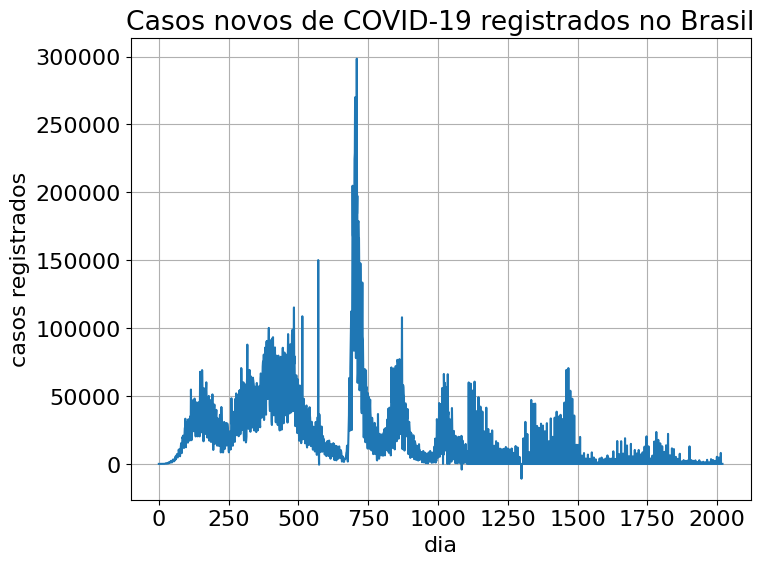

In [41]:
# Extrai os dados de casos  novos no Brasil para o vetor Brasilcasosnovos
Brasildados = df[df['regiao']=='Brasil']
Brasildados = Brasildados.sort_values(by='data')
Brasilcasosnovos = Brasildados['casosNovos'].to_numpy()

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams.update({'font.size': 16})
plt.plot( Brasilcasosnovos)
plt.title ('Casos novos de COVID-19 registrados no Brasil')
plt.ylabel('casos registrados')
plt.xlabel('dia')
plt.grid("minor")

In [7]:
# Projeto de um filtro FIR de fase linear com 64 coeficientes e frequência de
# corte pi/10 pelo método da janela utilizando uma janela de Blackman
N = 64
fc = 1/20

hideal = 2*fc* np.sinc(2*fc*np.arange(-N/2,N/2))
janela = np.blackman(N)
h = hideal*janela

Text(0.5, 0, '$\\Omega$')

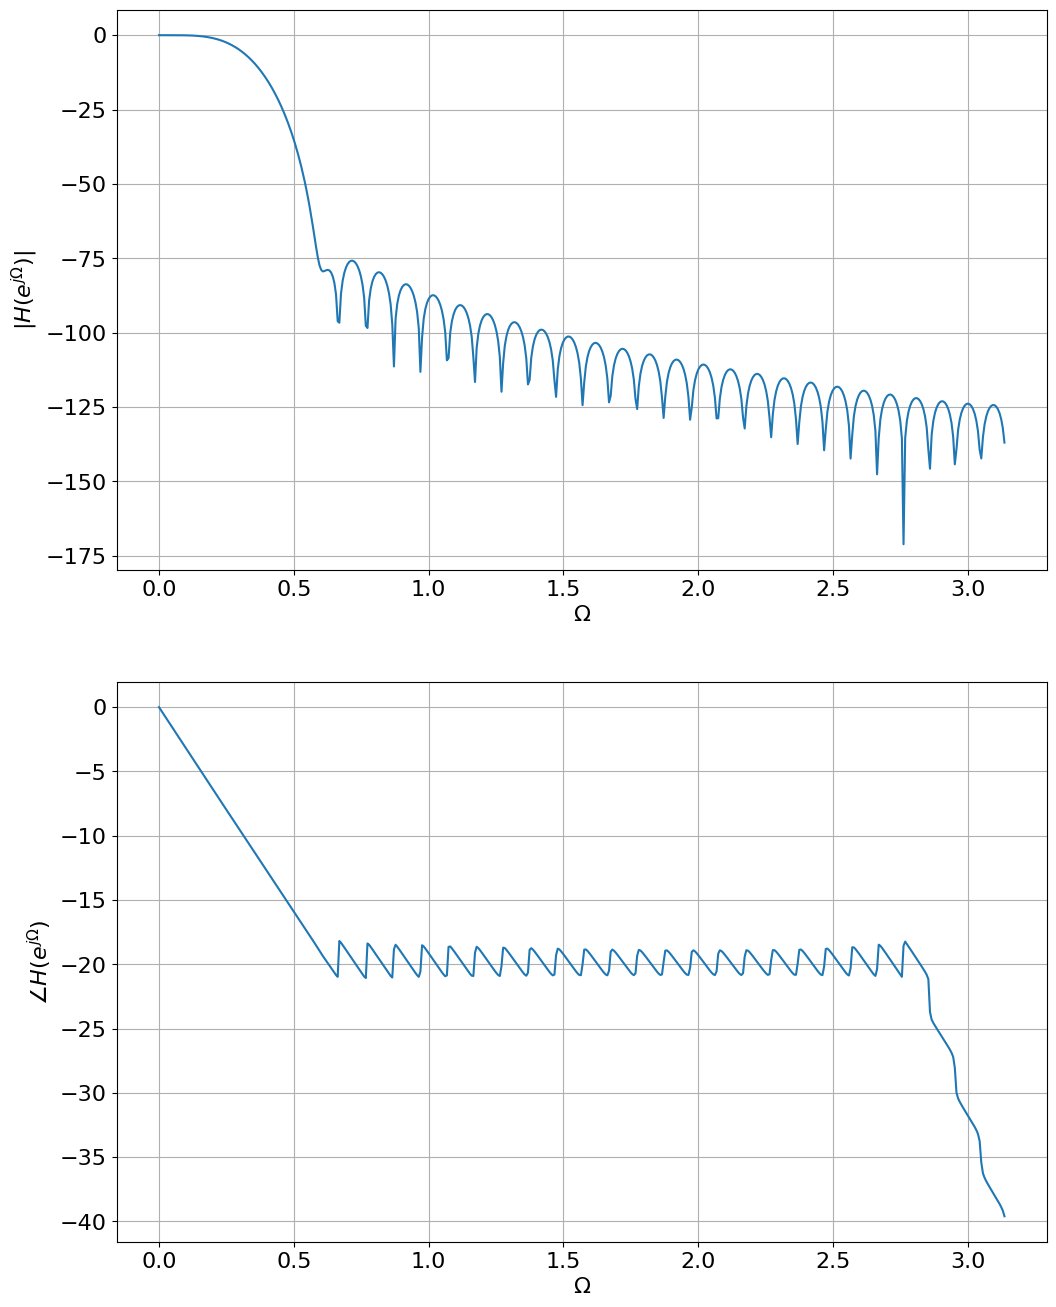

In [38]:
# Avaliação da resposta em frequência do filtro projetado
W,H = signal.freqz(h)

fig1, ax1 = plt.subplots(2,1)

ax1[0].plot(W,20*np.log10(abs(H)))
ax1[0].grid('minor')
ax1[0].set_ylabel(r'$|H(e^{j\Omega})|$')
ax1[0].set_xlabel(r'$\Omega$')

ax1[1].plot(W,np.unwrap(np.angle(H)))
ax1[1].grid('minor')
ax1[1].set_ylabel(r'$\angle  H(e^{j\Omega})$')
ax1[1].set_xlabel(r'$\Omega$')

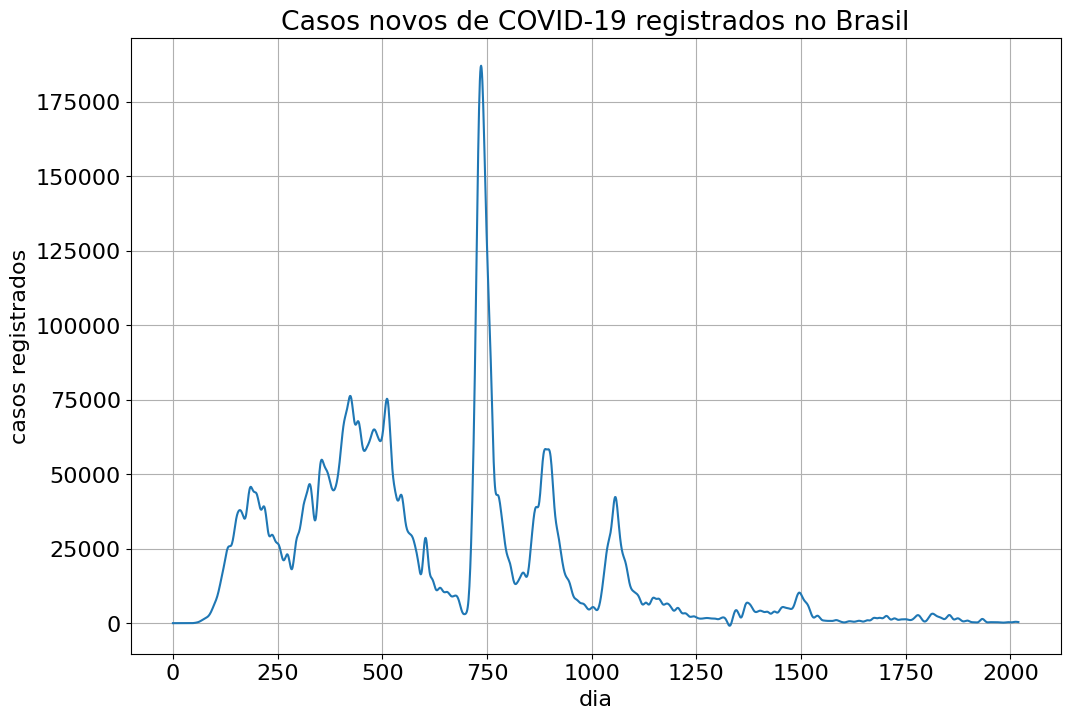

In [40]:
# Filtra os dados de casos novos no Brasil utilizando o filtro projetado
Brasilcasosnovosfiltrado = signal.lfilter(h,1,Brasilcasosnovos)
plt.plot(Brasilcasosnovosfiltrado)
plt.rcParams["figure.figsize"] = (8, 6)
plt.title ('Casos novos de COVID-19 registrados no Brasil')
plt.ylabel('casos registrados')
plt.xlabel('dia')
plt.grid("minor")

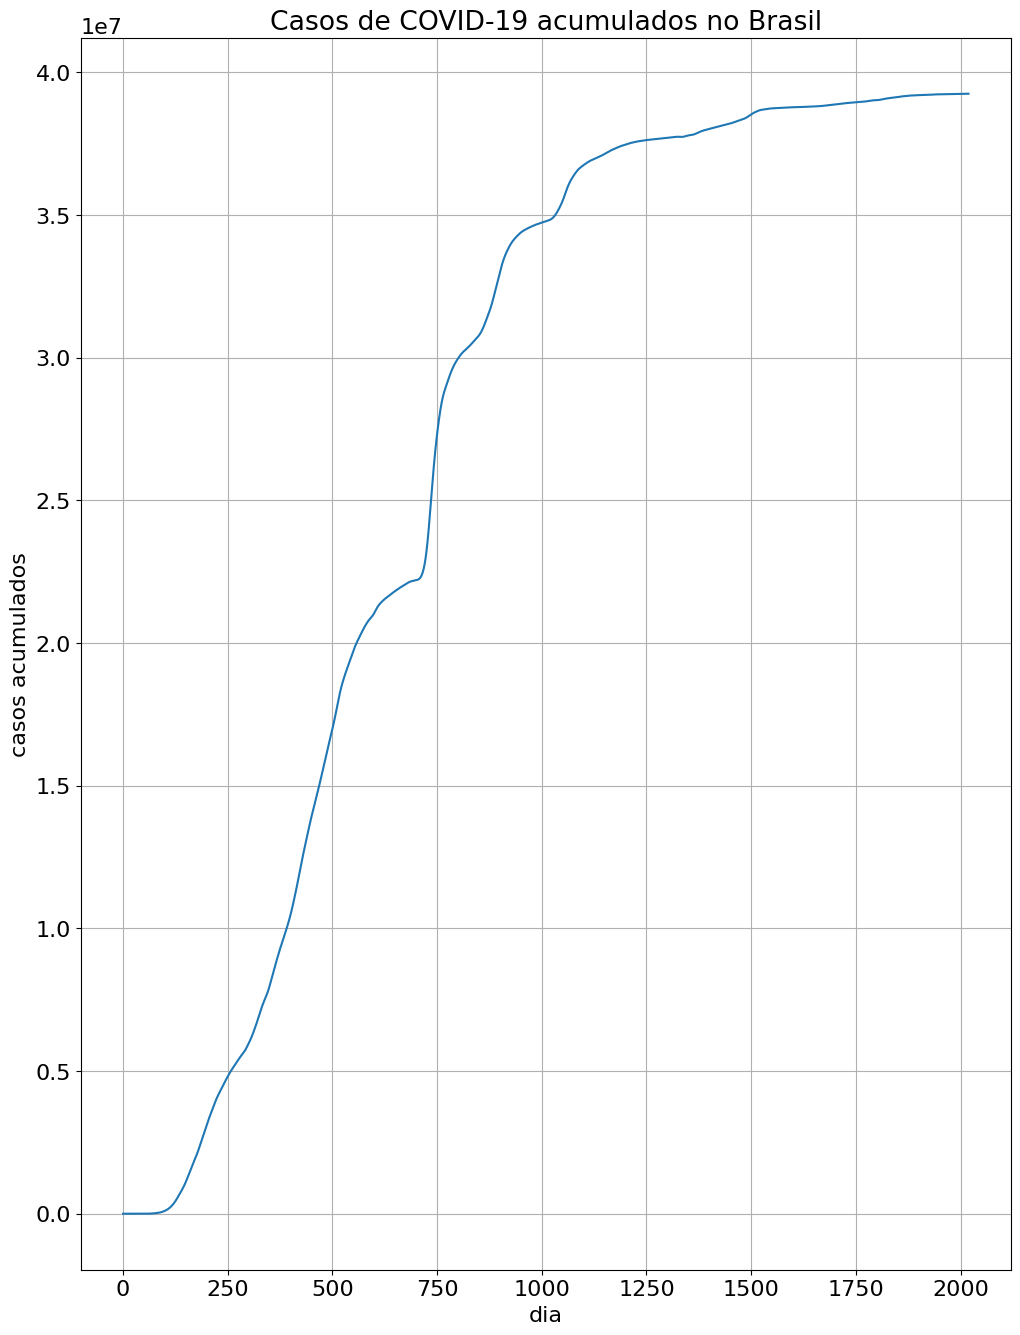

In [36]:
BrasilcasosAcumulados = signal.lfilter(1,[1, -1],Brasilcasosnovosfiltrado)
plt.plot(BrasilcasosAcumulados)
plt.title ('Casos de COVID-19 acumulados no Brasil')
plt.ylabel('casos acumulados')
plt.xlabel('dia')
plt.grid("minor")

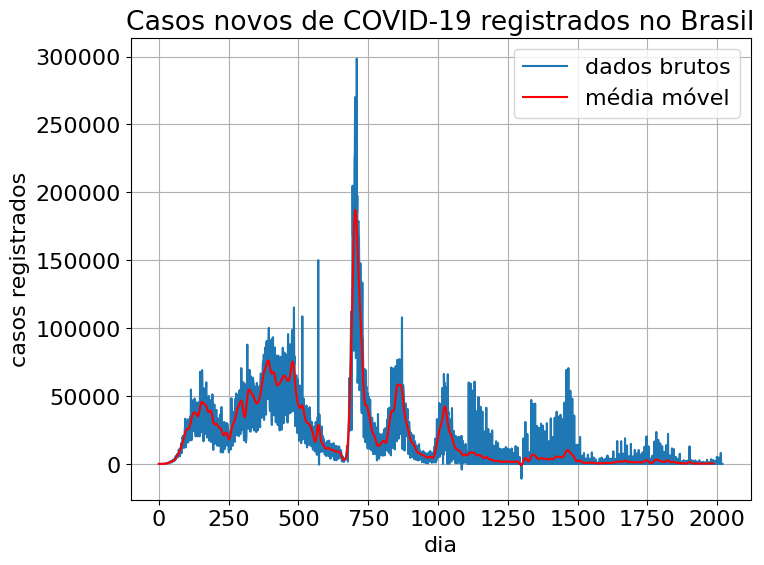

In [42]:
plt.plot( Brasilcasosnovos, label='dados brutos')
plt.plot( Brasilcasosnovosfiltrado[(N//2):], 'r', label='média móvel')
plt.title ('Casos novos de COVID-19 registrados no Brasil')
plt.ylabel('casos registrados')
plt.xlabel('dia')
plt.grid("minor")
plt.legend()

In [43]:
RSdados = df[(df['estado']=='RS')&(df['municipio'].isnull()) & (df['codmun'].isnull())]
RSdados = RSdados.sort_values(by='data')
RScasosnovos = RSdados['casosNovos'].to_numpy()

RScasosnovosfiltrado = signal.lfilter(h,1,RScasosnovos)

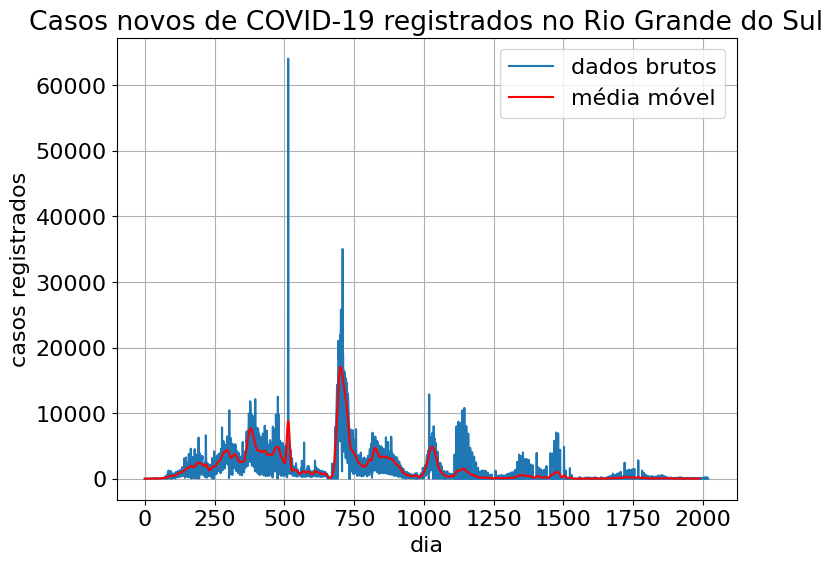

In [44]:
plt.plot( RScasosnovos, label='dados brutos')
plt.plot( RScasosnovosfiltrado[(N//2):], 'r', label='média móvel')
plt.title ('Casos novos de COVID-19 registrados no Rio Grande do Sul')
plt.ylabel('casos registrados')
plt.xlabel('dia')
plt.grid("minor")
plt.legend()

In [45]:
SMdados = df[(df['estado']=='RS') & (df['municipio']=='Santa Maria')]
SMdados = SMdados.sort_values(by='data')
SMcasosnovos = SMdados['obitosNovos'].to_numpy()

SMcasosnovosfiltrado = signal.lfilter(h,1,SMcasosnovos)

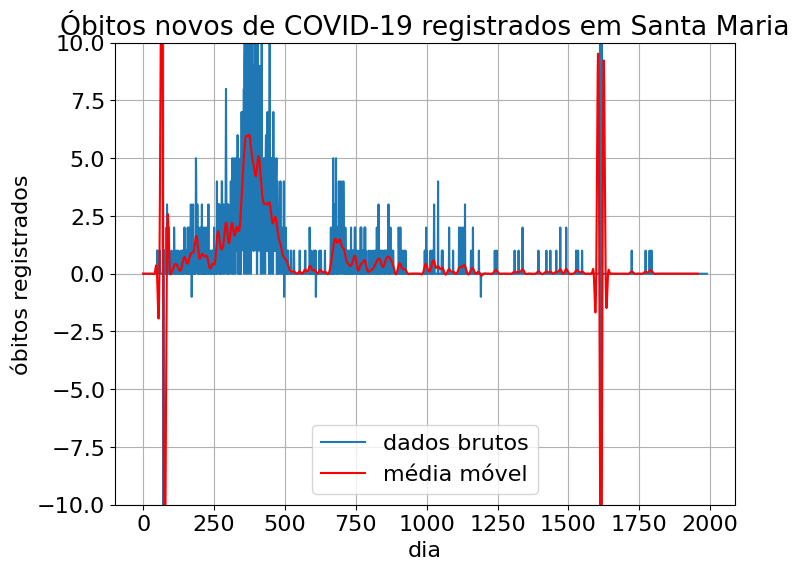

In [49]:
plt.plot( SMcasosnovos, label='dados brutos')
plt.plot( SMcasosnovosfiltrado[(N//2):], 'r', label='média móvel')
plt.title ('Óbitos novos de COVID-19 registrados em Santa Maria')
plt.ylabel('óbitos registrados')
plt.xlabel('dia')
plt.grid("minor")
plt.ylim([-10,10])
plt.legend()